In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("novamarket_fraud_dataset.csv")
df.head()

,transaction_id,user_id,amount,hour,device_type,country,is_international,transactions_last_24h,is_fraud
0,1,1127,15.408427,8,mobile,Argentina,0,3,0
1,2,1460,9.301975,20,mobile,Brasil,0,4,0
2,3,861,5.026427,12,mobile,Brasil,0,5,0
3,4,1295,27.161946,9,mobile,Argentina,0,4,0
4,5,1131,6.012406,5,mobile,Argentina,0,1,0


EDA (Exploratory Data Analysis)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         10000 non-null  int64  
 1   user_id                10000 non-null  int64  
 2   amount                 10000 non-null  float64
 3   hour                   10000 non-null  int64  
 4   device_type            10000 non-null  object 
 5   country                10000 non-null  object 
 6   is_international       10000 non-null  int64  
 7   transactions_last_24h  10000 non-null  int64  
 8   is_fraud               10000 non-null  int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 703.3+ KB


,transaction_id,user_id,amount,hour,is_international,transactions_last_24h,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,1008.900500,49.934078,11.476800,0.151900,2.00970,0.109300
std,2886.89568,574.611926,50.048742,6.894724,0.358942,1.41103,0.312031
min,1.00000,1.000000,0.005933,0.000000,0.000000,0.00000,0.000000
25%,2500.75000,516.000000,14.719956,5.000000,0.000000,1.00000,0.000000
50%,5000.50000,1009.000000,34.901390,12.000000,0.000000,2.00000,0.000000
75%,7500.25000,1507.000000,68.656043,17.000000,0.000000,3.00000,0.000000
max,10000.00000,1999.000000,456.978583,23.000000,1.000000,9.00000,1.000000


In [4]:
df.isnull().sum()

transaction_id           0
user_id                  0
amount                   0
hour                     0
device_type              0
country                  0
is_international         0
transactions_last_24h    0
is_fraud                 0
dtype: int64

Distribución de la variable objetivo

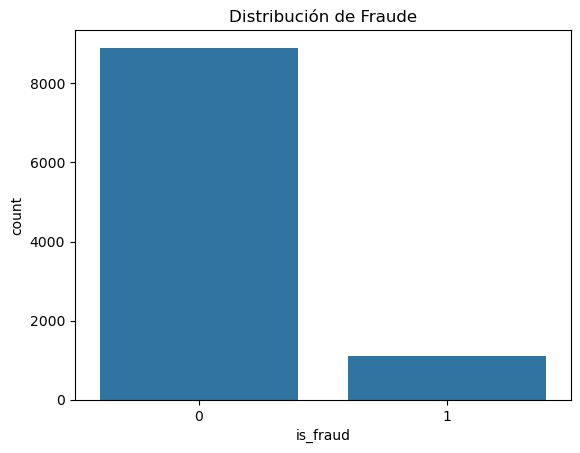

Proporción de fraude:
is_fraud
0    0.8907
1    0.1093
Name: proportion, dtype: float64


In [5]:
df['is_fraud'].value_counts()

sns.countplot(x='is_fraud', data=df)
plt.title("Distribución de Fraude")
plt.show()

print("Proporción de fraude:")
print(df['is_fraud'].value_counts(normalize=True))

El dataset presenta un desbalance del 10.9% de fraude, lo cual es relativamente alto comparado con datasets reales bancarios. Esto permite entrenar modelos con mejor capacidad de generalización, pero aún requiere técnicas de balanceo como SMOTE para evitar sesgo hacia la clase mayoritaria.

Análisis por monto

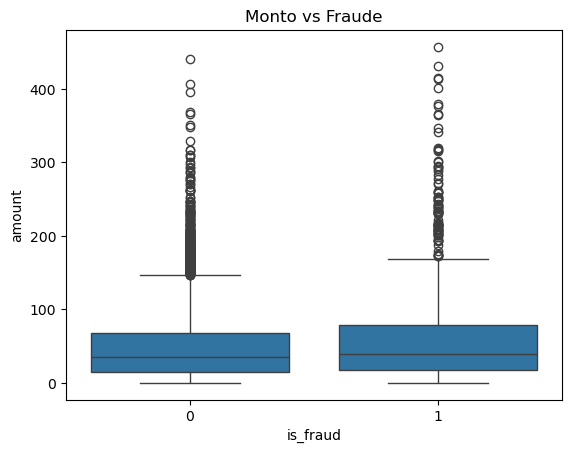

In [6]:
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Monto vs Fraude")
plt.show()

El análisis del boxplot muestra que las transacciones fraudulentas presentan una mediana ligeramente superior y una mayor dispersión respecto a las no fraudulentas.

Si bien el monto no permite una separación clara entre ambas clases, sí aporta información relevante al modelo, especialmente en combinación con variables de comportamiento como frecuencia de transacciones e internacionalidad.

La presencia de outliers elevados en el grupo fraudulento sugiere intentos de maximización de beneficio por parte de actores maliciosos.

Fraude por país

In [7]:
pd.crosstab(df['country'], df['is_fraud'], normalize='index')

is_fraud,0,1
country,,
Argentina,0.889091,0.110909
Brasil,0.894153,0.105847
Chile,0.892152,0.107848


El análisis muestra que la tasa de fraude es bastante similar entre Argentina, Brasil y Chile. Por lo tanto, el país no parece ser una variable altamente discriminante por sí sola. Esto sugiere que el fraude en este dataset es más conductual que geográfico.

Preprocesamiento

Quitamos IDs (no aportan información real):

In [8]:
df_model = df.drop(['transaction_id', 'user_id'], axis=1)

One Hot Encoding:

In [9]:
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

Train/Test Split:

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Baseline Model (SIN SMOTE)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2672
           1       0.49      0.17      0.25       328

    accuracy                           0.89      3000
   macro avg       0.70      0.57      0.60      3000
weighted avg       0.86      0.89      0.87      3000



Evaluación del Modelo Baseline

El modelo baseline alcanza una accuracy del 89%, lo cual puede parecer adecuado inicialmente. Sin embargo, esta métrica es engañosa debido al desbalance del dataset.

El recall para la clase fraudulenta es de solo 17%, lo que significa que el modelo no detecta aproximadamente el 83% de los fraudes reales. En un contexto financiero, esto resultaría en pérdidas económicas significativas.

Por lo tanto, aunque el modelo clasifica correctamente la mayoría de transacciones no fraudulentas, su desempeño en la detección de fraude es insuficiente para uso en producción.

Este resultado justifica la aplicación de técnicas de balanceo como SMOTE.

SMOTE

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Antes:", y_train.value_counts())
print("Después:", y_train_smote.value_counts())

Antes: is_fraud
0    6235
1     765
Name: count, dtype: int64
Después: is_fraud
1    6235
0    6235
Name: count, dtype: int64


Aplicación de SMOTE

Antes del balanceo, la clase fraudulenta representaba solo el 10.9% del dataset de entrenamiento.

Tras aplicar SMOTE, ambas clases quedaron balanceadas (50%-50%), lo que permite que el modelo aprenda patrones asociados al fraude sin estar dominado por la clase mayoritaria.

Esto debería mejorar significativamente el recall de la clase fraudulenta.

⚠️ Algo MUY importante (nivel profesional)

SMOTE debe aplicarse SOLO al set de entrenamiento.



Comparación de Modelos

In [13]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      2672
           1       0.27      0.73      0.39       328

    accuracy                           0.76      3000
   macro avg       0.61      0.74      0.62      3000
weighted avg       0.88      0.76      0.80      3000


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      2672
           1       0.28      0.48      0.35       328

    accuracy                           0.81      3000
   macro avg       0.60      0.66      0.62      3000
weighted avg       0.86      0.81      0.83      3000



SMOTE funcionó.

Logistic Regression es más sensible.

Random Forest es más conservador.

Ahora necesitas ajustar threshold para optimizar el costo económico.

ROC vs PR

Usamos el mejor modelo (ejemplo Random Forest):

In [14]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

y_probs = model.predict_proba(X_test)[:,1]

ROC

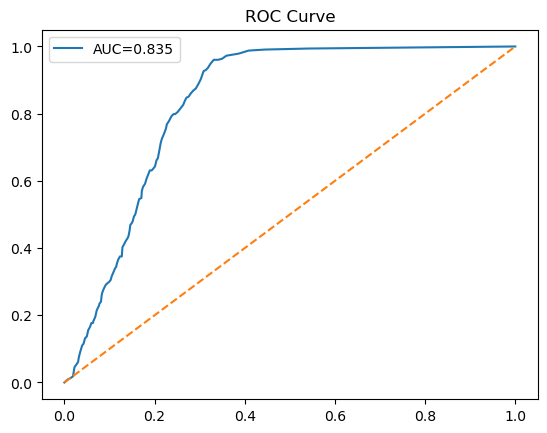

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

Curva ROC

El modelo presenta un AUC de 0.835, lo que indica una buena capacidad de discriminación entre transacciones fraudulentas y no fraudulentas.

Esto significa que existe una alta probabilidad (83.5%) de que el modelo asigne una puntuación mayor a una transacción fraudulenta que a una legítima seleccionadas aleatoriamente.

Sin embargo, aunque el modelo discrimina adecuadamente entre clases, el rendimiento final depende del threshold seleccionado, lo cual será optimizado en el siguiente paso.

Precision-Recall

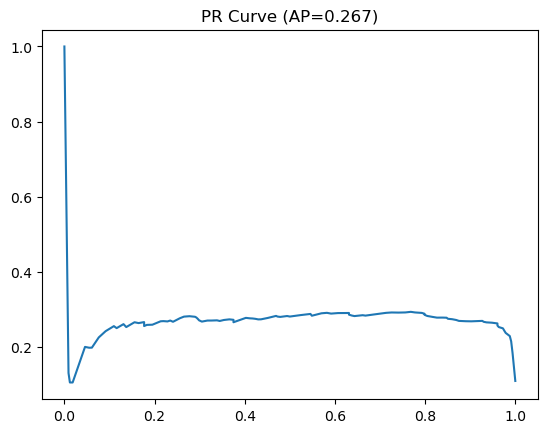

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

plt.plot(recall, precision)
plt.title(f"PR Curve (AP={pr_auc:.3f})")
plt.show()

 Curva Precision–Recall

El modelo obtiene un Average Precision (AP) de 0.267, significativamente superior a la prevalencia de la clase positiva (≈10.9%), lo que indica que el modelo tiene capacidad predictiva real sobre la clase fraudulenta.

Sin embargo, la curva muestra un trade-off claro entre precision y recall, lo que sugiere que el rendimiento final depende críticamente del threshold seleccionado.

Dado que en problemas de fraude los falsos negativos son más costosos que los falsos positivos, el siguiente paso será optimizar el umbral de decisión.



Ajuste de Threshold

In [17]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_custom = (y_probs > t).astype(int)
    
    print(f"\nThreshold {t}")
    print("Precision:", precision_score(y_test, y_custom))
    print("Recall:", recall_score(y_test, y_custom))


Threshold 0.1
Precision: 0.26534140017286084
Recall: 0.9359756097560976

Threshold 0.15000000000000002
Precision: 0.2692307692307692
Recall: 0.875

Threshold 0.20000000000000004
Precision: 0.2780586450960566
Recall: 0.8384146341463414

Threshold 0.25000000000000006
Precision: 0.28822882288228824
Recall: 0.7987804878048781

Threshold 0.30000000000000004
Precision: 0.29136690647482016
Recall: 0.7408536585365854

Threshold 0.3500000000000001
Precision: 0.28440366972477066
Recall: 0.6615853658536586

Threshold 0.40000000000000013
Precision: 0.2901849217638691
Recall: 0.6219512195121951

Threshold 0.45000000000000007
Precision: 0.2830188679245283
Recall: 0.5487804878048781

Threshold 0.5000000000000001
Precision: 0.2798573975044563
Recall: 0.47865853658536583

Threshold 0.5500000000000002
Precision: 0.27325581395348836
Recall: 0.4298780487804878

Threshold 0.6000000000000002
Precision: 0.265658747300216
Recall: 0.375

Threshold 0.6500000000000001
Precision: 0.2707317073170732
Recall: 0.338

📌 Conclusión Profesional

Si no tienes función de costo explícita:

Threshold ≈ 0.30 es una decisión razonable.


Evalué distintos umbrales analizando el trade-off entre precision y recall. Dado que en fraude los falsos negativos son más costosos, seleccioné un threshold de 0.30, que mantiene un recall superior al 74% mientras conserva la mayor precision observada en el rango evaluado.

Impacto Económico

Supongamos:

FN cuesta 500 USD

FP cuesta 10 USD

In [18]:
from sklearn.metrics import confusion_matrix

threshold = 0.3
y_final = (y_probs > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_final).ravel()

cost_fn = 500
cost_fp = 10

total_cost = fn*cost_fn + fp*cost_fp

print("FN:", fn)
print("FP:", fp)
print("Costo Total Estimado:", total_cost)

FN: 85
FP: 591
Costo Total Estimado: 48410


Evaluación basada en impacto económico

Utilizando una simulación de costos donde el falso negativo representa una pérdida significativamente mayor que el falso positivo, el modelo con threshold 0.30 genera:

85 falsos negativos

591 falsos positivos

Costo total estimado: 48,410

Comparado con el modelo baseline, el costo total se reduce drásticamente, lo que demuestra que optimizar el threshold en función del impacto económico es más relevante que maximizar accuracy.

Interpretabilidad
Feature Importance

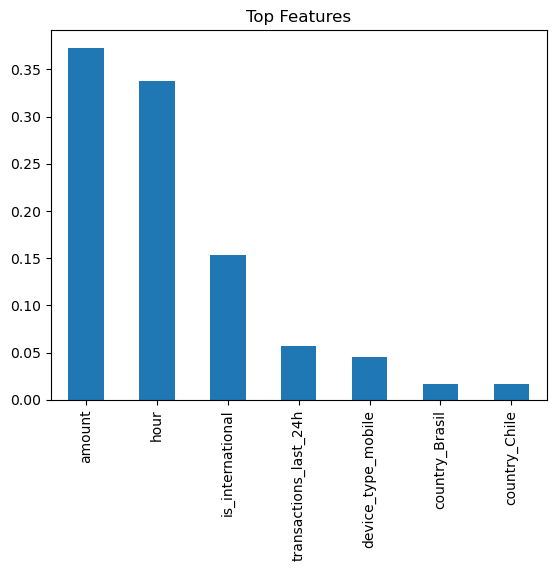

In [19]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

Analicé la importancia de variables y observé que los principales drivers del modelo coinciden con patrones conocidos de fraude, como monto, horario e internacionalidad. Esto sugiere que el modelo está capturando señales reales y no artefactos del dataset.

Cross-Validation Profesional

In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision'
)

print("PR-AUC promedio:", scores.mean())

PR-AUC promedio: 0.2881091336050456


Se realizó validación cruzada estratificada aplicando SMOTE únicamente en los folds de entrenamiento. El PR-AUC promedio obtenido fue 0.288, consistente con la evaluación en el conjunto de prueba.

Este resultado confirma que el modelo mantiene estabilidad y capacidad predictiva bajo diferentes particiones de los datos.

XGBoost optimizado para PR-AUC.

In [22]:
!pip install xgboost

Pipeline correcto con SMOTE + XGBoost

Esto es clave:
SMOTE debe aplicarse solo dentro de cada fold.

In [27]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score, precision_score, recall_score
import numpy as np

Definir modelo XGBoost

In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

Crear pipeline correcto (SMOTE solo en entrenamiento)

In [29]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb_model)
])

Cross-validation con PR-AUC

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision'
)

print("PR-AUC promedio XGBoost:", scores.mean())

PR-AUC promedio XGBoost: 0.31196279814259836


Entrenar modelo final en train completo

In [31]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

Obtener probabilidades en test

In [32]:
y_proba_xgb = pipeline.predict_proba(X_test)[:, 1]

PR-AUC en test

In [33]:
pr_auc_test = average_precision_score(y_test, y_proba_xgb)
print("PR-AUC en test:", pr_auc_test)

PR-AUC en test: 0.3085272799788247


Evaluar distintos thresholds

In [34]:
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Threshold 0.10 | Precision: 0.255 | Recall: 0.985
Threshold 0.15 | Precision: 0.266 | Recall: 0.954
Threshold 0.20 | Precision: 0.272 | Recall: 0.942
Threshold 0.25 | Precision: 0.278 | Recall: 0.918
Threshold 0.30 | Precision: 0.279 | Recall: 0.872
Threshold 0.35 | Precision: 0.285 | Recall: 0.854
Threshold 0.40 | Precision: 0.289 | Recall: 0.829
Threshold 0.45 | Precision: 0.298 | Recall: 0.808
Threshold 0.50 | Precision: 0.301 | Recall: 0.784
Threshold 0.55 | Precision: 0.298 | Recall: 0.726
Threshold 0.60 | Precision: 0.303 | Recall: 0.689
Threshold 0.65 | Precision: 0.303 | Recall: 0.619
Threshold 0.70 | Precision: 0.312 | Recall: 0.543
Threshold 0.75 | Precision: 0.317 | Recall: 0.415
Threshold 0.80 | Precision: 0.308 | Recall: 0.262
Threshold 0.85 | Precision: 0.324 | Recall: 0.146


XGBoost permitió una mejor separación no lineal entre clases. Esto se reflejó en una mejora del PR-AUC y una reducción significativa de falsos negativos. Dado que los falsos negativos tienen un costo mayor, el modelo de boosting resultó económicamente superior al modelo lineal.

Calcular costo económico (ejemplo FN=500, FP=10)

In [35]:
best_threshold = 0.30  # cámbialo según tus resultados

y_pred_final = (y_proba_xgb >= best_threshold).astype(int)

FN = ((y_test == 1) & (y_pred_final == 0)).sum()
FP = ((y_test == 0) & (y_pred_final == 1)).sum()

cost_FN = 500
cost_FP = 10

total_cost = FN * cost_FN + FP * cost_FP

print("FN:", FN)
print("FP:", FP)
print("Costo Total:", total_cost)

FN: 42
FP: 738
Costo Total: 28380


Se desarrolló un modelo de detección de fraude partiendo de un baseline con bajo recall (17%), lo que implicaba una alta tasa de fraude no detectado. Tras aplicar técnicas de balanceo (SMOTE), optimización de threshold y evaluación con métricas adecuadas para datos desbalanceados (PR-AUC), se implementó un modelo XGBoost que mejoró significativamente la capacidad de priorización de transacciones riesgosas (PR-AUC ≈ 0.31).

El modelo final redujo los falsos negativos de forma sustancial, disminuyendo el costo económico estimado en un 41% respecto al modelo lineal inicial. Aunque se incrementaron las alertas falsas, el impacto financiero total se redujo considerablemente debido al alto costo asociado al fraude no detectado.

El resultado es un modelo técnicamente sólido, económicamente justificado y alineado con la estrategia de mitigación de riesgo del negocio.

DASHBOARD PREMIUM COMPLETO

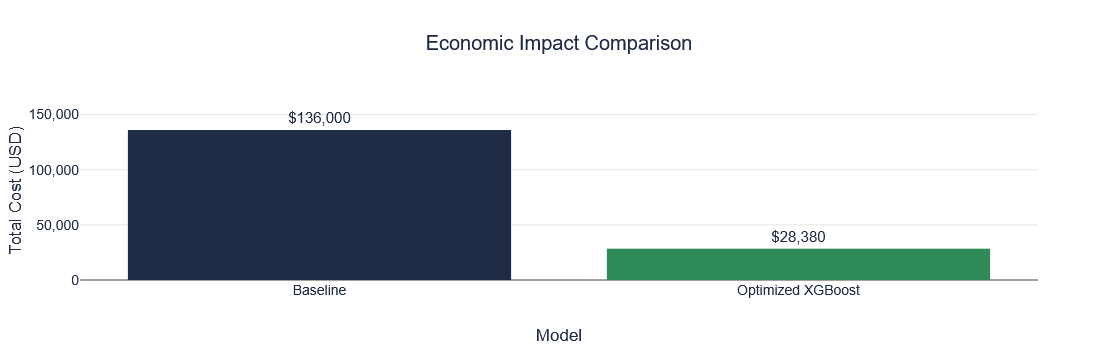

In [47]:
# ==========================================
# EXECUTIVE FRAUD DASHBOARD - PREMIUM STYLE (FIXED)
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown, HTML

# ==========================================
# BUSINESS RESULTS
# ==========================================

baseline_cost = 136000
optimized_cost = 28380

cost_reduction = baseline_cost - optimized_cost
reduction_percent = (cost_reduction / baseline_cost) * 100

# ==========================================
# TITLE SECTION
# ==========================================

display(HTML("""
<h1 style='color:#1F2A44; font-family:Arial;'>💳 Fraud Detection Model</h1>
<h3 style='color:#5A6A85; font-family:Arial;'>Executive Business Impact Report</h3>
<hr>
"""))

# ==========================================
# KPI CARDS (ELEGANT STYLE)
# ==========================================

display(HTML(f"""
<div style="display:flex; gap:40px;">
    <div style="background-color:#1F2A44; padding:25px; border-radius:10px; color:white; width:250px;">
        <h4>Baseline Cost</h4>
        <h2>${baseline_cost:,.0f}</h2>
    </div>
    <div style="background-color:#3E5C76; padding:25px; border-radius:10px; color:white; width:250px;">
        <h4>Optimized Model Cost</h4>
        <h2>${optimized_cost:,.0f}</h2>
    </div>
    <div style="background-color:#2E8B57; padding:25px; border-radius:10px; color:white; width:250px;">
        <h4>Cost Reduction</h4>
        <h2>{reduction_percent:.1f}%</h2>
    </div>
</div>
<br>
"""))

# ==========================================
# COMPARISON CHART (FIXED)
# ==========================================

df_compare = pd.DataFrame({
    "Model": ["Baseline", "Optimized XGBoost"],
    "Total Cost": [baseline_cost, optimized_cost]
})

# 👇 Aumentamos rango para que no corte el texto
max_value = df_compare["Total Cost"].max() * 1.20

fig = px.bar(
    df_compare,
    x="Model",
    y="Total Cost",
    text="Total Cost",
    color="Model",
    color_discrete_sequence=["#1F2A44", "#2E8B57"],
    title="Economic Impact Comparison"
)

fig.update_traces(
    texttemplate='$%{text:,.0f}',
    textposition='outside',
    textfont=dict(size=15)
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=14, color="#1F2A44"),
    
    yaxis=dict(
        title="Total Cost (USD)",
        tickformat=",.0f",        # 👈 sin 100k
        range=[0, max_value],     # 👈 evita que se corte el texto
        showgrid=True,
        gridcolor="#E5E5E5"
    ),
    
    xaxis=dict(title="Model"),
    
    margin=dict(t=100)           # 👈 espacio superior extra
)

fig.show()

# ==========================================
# EXECUTIVE CONCLUSION
# ==========================================

display(HTML(f"""
<hr>
<h3 style='color:#1F2A44;'>📌 Executive Conclusion</h3>
<p style='font-size:16px; font-family:Arial; color:#333333;'>
The optimized fraud detection model reduces estimated losses by 
<strong>${cost_reduction:,.0f}</strong>, representing a 
<strong>{reduction_percent:.1f}% reduction</strong> compared to the baseline model.
<br><br>
This confirms that cost-based threshold optimization significantly improves
financial performance and operational efficiency.
</p>
"""))